# 06 Feature Adoption

## Goal

Treat observable product behaviors as features and evaluate which behaviors relate to retention or revenue.

## Setup

Connect to the local DuckDB database created by the transformation pipeline.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from product_growth_analytics.notebook_utils import connect, query_df, read_sql

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
con = connect()

## Concept

In event analytics, features are not always UI components. A feature can be a behavior the product enables, such as carting, purchasing, category browsing, or brand browsing.

In [2]:
feature_adoption = query_df(con, read_sql("analysis/feature_adoption.sql"))
feature_adoption

,feature,events,adopting_users,adopting_sessions
0,view,104335509,5316128,23005603
1,cart,3955446,1054133,2316432
2,purchase,1659788,697470,1402758


In [3]:
user_features = query_df(con, """
SELECT
    user_id,
    view_events > 0 AS adopted_view,
    cart_events > 0 AS adopted_cart,
    purchase_events > 0 AS adopted_purchase,
    categories_engaged,
    known_brands_engaged,
    revenue
FROM analytics.mart_user_lifecycle
""")
user_features.head()

,user_id,adopted_view,adopted_cart,adopted_purchase,categories_engaged,known_brands_engaged,revenue
0,534313202,True,False,False,7,8,0.0000
1,563227152,True,False,False,3,2,0.0000
2,561293561,True,True,False,16,34,0.0000
3,555765184,True,True,False,10,16,0.0000
4,524843394,True,False,False,3,2,0.0000


In [4]:
adoption_revenue = user_features.groupby("adopted_cart").agg(
    users=("user_id", "nunique"),
    avg_revenue=("revenue", "mean"),
    purchase_rate=("adopted_purchase", "mean"),
).reset_index()
adoption_revenue

,adopted_cart,users,avg_revenue,purchase_rate
0,False,4262516,9.8500,0.0309
1,True,1054133,439.3816,0.5369


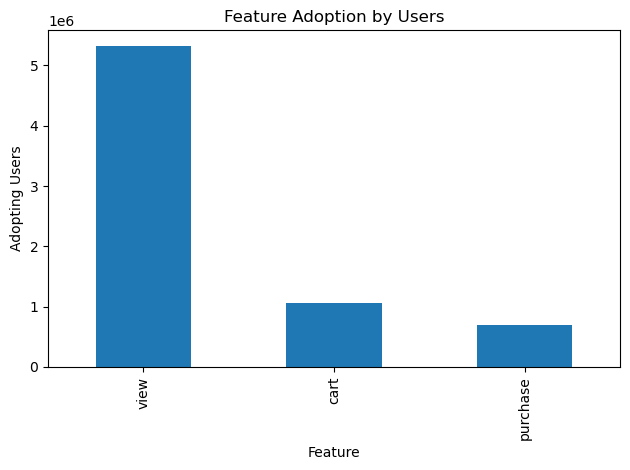

In [5]:
ax = feature_adoption.plot(kind="bar", x="feature", y="adopting_users", legend=False, title="Feature Adoption by Users")
ax.set_xlabel("Feature")
ax.set_ylabel("Adopting Users")
plt.tight_layout()

## Takeaways

- Product viewing is nearly universal: **5,316,128 users** adopted `view`, compared with **1,054,133 cart users** and **697,470 purchasing users**.
- Cart behavior is a strong intent signal. Users who adopted cart had an average revenue of **439.38** and a **53.69% purchase rate**, while users who did not adopt cart had average revenue of **9.85** and only a **3.09% purchase rate**.
- Buyers engage more broadly than non-buyers: purchasing users engaged with an average of **6.49 categories** and **9.67 known brands**, compared with **2.71 categories** and **3.56 known brands** for non-purchasers.
- Repeat purchasers show even deeper breadth: repeat buyers engaged with an average of **8.98 categories** and **13.41 known brands**, versus **5.43 categories** and **8.07 known brands** for one-time buyers.
- Repeat purchasers also have much higher observed revenue: **1,602.63 average revenue** versus **347.96** for non-repeat purchasers.
- These relationships are correlational, not causal. Cart adoption and broader category/brand exploration may indicate stronger shopping intent, but an experiment would be needed to prove that nudging these behaviors increases purchase or retention.

Overall, cart adoption and browsing breadth are useful behavioral signals for lifecycle segmentation. Product should investigate whether better recommendations, category discovery, or cart nudges can move high-intent browsers toward repeat purchase.